<a href="https://colab.research.google.com/github/yuanzhouwang/ConformalHMM/blob/main/hmm_conformal_batched.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast Conformal Prediction on Hidden Markov Models

This notebook provides the core algorithm for conformal prediction on Hidden Markov Models, as well as fast algorithm that makes use of Monte Carlo Sampling.


## The Canonical Approach
This algorithm assumes:
- `X[:t=0 to t=T]` contains known past hidden states,
- `Y[:t=0 to t=T+T_1]` contains observations through the future horizon,
- `x_future` is one hypothesized future hidden path of length `T1`.

By setting `use_all_permutations=False`, the algorithm provides the canoncial approach for evaluating a single candidate future hidden path, which can be adapted to Algorithm 1 by simply iterating through all possible future hidden paths.

## The Fast Approach
This algorithm assumes the same as above, with additionally:
- `max_permutations` sets the sample size to be drawn from the permutation set.

By setting `use_all_permutations=False`, the algorithm samples random permutations from the set of all possible permutations constructed of the blocks using `.rng.permutation()`. Again, this is used to evaluate only a single candidate future hidden path.

### 1. Imports

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from itertools import permutations
from typing import List, Sequence, Tuple, Dict, Optional
from itertools import product

import zstandard as zstd
import shutil
import math
import numpy as np
import pandas as pd
from google.colab import files
import time
import torch

In [ ]:
uploaded = files.upload()
X_vars = np.load("tempX.npy")
uploaded = files.upload()
Y_vars = pd.read_csv("dmid_1x10000_scaled_transposed.csv")

In [ ]:
X_test = X_vars.T
np.max(Y_vars)-np.min(Y_vars)

# Convert Y_vars.T to a numpy array
Y_test_base = Y_vars.T.values

# Generate random noise of the same shape as Y_test_base
# Using a small standard deviation (e.g., 0.01) for the noise
noise_scale = 0.01
random_noise = np.random.normal(0, noise_scale, Y_test_base.shape)

# Create the noisy copy
noisy_Y_test = Y_test_base + random_noise

# Concatenate the original and noisy copy to get a (10000, 2) array
Y_test = np.hstack((Y_test_base, noisy_Y_test))

### 3. K-Means for estimating hidden states

In [ ]:
def k_means(
    X: np.ndarray,
    k: int,
    max_iters: int = 100,
    random_state: Optional[int] = None
) -> Tuple[np.ndarray, List[Tuple[np.ndarray, np.ndarray]]]:
    """
    Performs K-Means clustering on the input data X.

    Parameters
    ----------
    X : np.ndarray
        A NumPy array of d-dimensional vectors (n_samples, d_features).
    k : int
        The number of clusters.
    max_iters : int, optional
        The maximum number of iterations for the algorithm, by default 100.
    random_state : Optional[int], optional
        Seed for the random number generator for centroid initialization, by default None.

    Returns
    -------
    Tuple[np.ndarray, List[Tuple[np.ndarray, np.ndarray]]]
        - cluster_labels: A NumPy array of shape (n_samples,) indicating the cluster
                          assignment for each data point.
        - cluster_bounds: A list of tuples, where each tuple contains (min_values, max_values)
                          for each dimension within a cluster. Empty clusters will not have bounds.
    """

    n_samples, n_features = X.shape

    if n_samples < k:
        raise ValueError("Number of samples must be greater than or equal to k")

    rng = np.random.default_rng(random_state)

    # 3. Initialize k centroids by randomly selecting k unique data points from X.
    # Ensure unique indices for initial centroids
    initial_indices = rng.choice(n_samples, k, replace=False)
    centroids = X[initial_indices].astype(float)

    cluster_labels = np.zeros(n_samples, dtype=int)

    # 4. Start an iterative loop
    for _ in range(max_iters):
        # a. For each data point, calculate its Euclidean distance to all k centroids.
        # distances shape: (n_samples, k)
        distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))

        # b. Assign each data point to the cluster of the closest centroid.
        new_cluster_labels = np.argmin(distances, axis=1)

        # c. Calculate the new centroids by taking the mean of all data points assigned to each cluster.
        new_centroids = np.copy(centroids)
        for i in range(k):
            points_in_cluster = X[new_cluster_labels == i]
            if len(points_in_cluster) > 0:
                new_centroids[i] = np.mean(points_in_cluster, axis=0)
            # else: Centroid remains unchanged if the cluster is empty (as per instruction suggestion)

        # d. Check for convergence: If the new centroids are identical to the old centroids, break.
        if np.array_equal(new_centroids, centroids):
            cluster_labels = new_cluster_labels
            break

        centroids = new_centroids
        cluster_labels = new_cluster_labels # Update labels for the final pass if convergence not met

    # 5. After the loop terminates, calculate the cluster bounds:
    cluster_bounds: List[Tuple[np.ndarray, np.ndarray]] = []
    for i in range(k):
        points_in_cluster = X[cluster_labels == i]
        if len(points_in_cluster) > 0:
            min_values = np.min(points_in_cluster, axis=0)
            max_values = np.max(points_in_cluster, axis=0)
            cluster_bounds.append((min_values, max_values))

    return cluster_labels, cluster_bounds


### 4. Model and Scoring

In [ ]:
@dataclass
class ConformalResult:
    q_hat: float
    identity_score: float
    scores: List[float]
    accepted: bool
    P_hat: np.ndarray
    B_hat: np.ndarray
    blocks: List[List[Tuple[int, int]]]
    permutations: List[Tuple[int, ...]]
    n_blocks: int
    n_permutations_used: int
    n_permutations_total: int
    elapsed: float

class SinglePath:
    """
    Algorithm 1 for a single given candidate
    future hidden path.

    Conventions:
    - X contains known hidden states only up to T
    - Y contains observations up to T + T1
    - x_future is a proposed hidden path of length T1

    We set T and evaluate the candidate path x_future
    over the future window T+1, ..., T+T1.

    Theoretical Implications of Selective Permutation Strategy:
    The original conformal prediction algorithm typically relies on an exchangeability
    assumption for the entire sequence of data blocks. In this modified `SinglePath` class,
    a selective permutation strategy is employed: instead of permuting all blocks, only
    blocks within the future horizon (from `T` to `T+T1`) are permuted, while the past
    sequence (up to `T`) remains fixed.

    This approach deviates from the full exchangeability assumption of the canonical
    algorithm. The theoretical validity of conformal guarantees (e.g., coverage probability)
    is typically established under full exchangeability of blocks. By fixing the past sequence
    and only permuting future blocks, we are implicitly assuming a different form of exchangeability,
    potentially conditional on the past. This modification aims to reflect scenarios where
    the past is observed and non-exchangeable with the future, but the future blocks are
    exchangeable among themselves. However, the exact impact on the finite-sample or asymptotic
    conformal guarantees requires careful theoretical analysis. Further theoretical justification
    might be required to rigorously establish the validity and coverage properties of the
    conformal prediction sets generated by this modified approach.
    """

    def __init__(
        self,
        threshold: Optional[float] = None,
        state_values: Optional[Sequence[int]] = None,
        obs_values: Optional[Sequence[int]] = None,
        smoothing: float = 1e-8,
        use_all_permutations: bool = False,
        max_permutations: int = 200,
        random_seed: Optional[int] = None,
        device: Optional[str] = None,
        batch_size: int = 4096,
    ) -> None:
        self.threshold = threshold
        self.state_values = state_values
        self.obs_values = obs_values
        self.smoothing = smoothing
        self.use_all_permutations = use_all_permutations
        self.max_permutations = max_permutations
        self.rng = np.random.default_rng(random_seed)
        self.batch_size = batch_size

        # CHANGE: keep a single model object alive and place batched tensor work on CPU/GPU.
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(device)
        self.dtype = torch.float64

        self.state_to_idx: Dict[int, int] = {}
        self.obs_to_idx: Dict[int, int] = {}
        self.idx_to_state: Dict[int, int] = {}
        self.idx_to_obs: Dict[int, int] = {}

        # CHANGE: persistent fitted objects so we precompute the past only once.
        self.is_fitted = False
        self.T: Optional[int] = None
        self.T1: Optional[int] = None
        self.n_states: Optional[int] = None
        self.n_obs: Optional[int] = None
        self.X_past_enc: Optional[np.ndarray] = None
        self.Y_all_enc: Optional[np.ndarray] = None
        self.Y_future_enc_np: Optional[np.ndarray] = None
        self.x_last_np: Optional[int] = None
        self.Y_future_torch: Optional[torch.Tensor] = None
        self.x_last_torch: Optional[torch.Tensor] = None
        self.past_trans_counts: Optional[torch.Tensor] = None
        self.past_trans_row_totals: Optional[torch.Tensor] = None
        self.past_emit_counts: Optional[torch.Tensor] = None
        self.past_emit_row_totals: Optional[torch.Tensor] = None

    def fit(
        self,
        X: Sequence[int],
        Y: Sequence[int],
        T: int,
        T1: int,
    ) -> "SinglePath":
        """
        CHANGE: fit once on the fixed past and future observations, then reuse.
        This avoids rebuilding encoders and re-estimating past counts for every path.
        """
        self._validate_fit_inputs(X, Y, T, T1)

        X_past = np.asarray(X, dtype=int).reshape(-1)
        Y_all = np.asarray(Y).reshape(-1)

        self._build_encoders(X_past, Y_all)

        X_past_enc = self._encode_states(X_past)
        Y_all_enc = self._encode_obs(Y_all)

        self.T = T
        self.T1 = T1
        self.n_states = len(self.state_to_idx)
        self.n_obs = len(self.obs_to_idx)
        self.X_past_enc = X_past_enc
        self.Y_all_enc = Y_all_enc
        self.Y_future_enc_np = Y_all_enc[T:]
        self.x_last_np = int(X_past_enc[-1])

        # CHANGE: precompute all past transition/emission counts a single time.
        self.past_trans_counts, self.past_trans_row_totals = self._precompute_past_transition_counts(X_past_enc)
        self.past_emit_counts, self.past_emit_row_totals = self._precompute_past_emission_counts(X_past_enc, Y_all_enc[:T])

        self.Y_future_torch = torch.as_tensor(self.Y_future_enc_np, dtype=torch.long, device=self.device)
        self.x_last_torch = torch.tensor(self.x_last_np, dtype=torch.long, device=self.device)
        self.is_fitted = True
        return self

    def evaluate_given_path(
        self,
        X: Sequence[int],
        Y: Sequence[int],
        T: int,
        T1: int,
        x_future: Sequence[int],
    ) -> ConformalResult:
        """
        Evaluate a single candidate future hidden path.
        """
        if not self.is_fitted:
            self.fit(X=X, Y=Y, T=T, T1=T1)

        if self.T != T or self.T1 != T1:
            raise ValueError("Model has been fit on a different (T, T1) configuration.")

        x_future_enc = self._encode_states(np.asarray(x_future, dtype=int).reshape(-1))
        return self._evaluate_single_encoded_path(x_future_enc)

    def evaluate_all_paths(
        self,
        X: Sequence[int],
        Y: Sequence[int],
        T: int,
        T1: int,
        candidate_paths: Sequence[Sequence[int]],
        threshold: Optional[float] = None,
    ):
        """
        If threshold is provided, return the conformal set.
        Otherwise return all q_hat values.
        """
        path_qhats = self.compute_all_qhats(
            X=X,
            Y=Y,
            T=T,
            T1=T1,
            candidate_paths=candidate_paths,
        )

        if threshold is None:
            return path_qhats

        conformal_set = self.conformal_set_from_qhats(path_qhats, threshold)
        return conformal_set, path_qhats

    def _validate_fit_inputs(
        self,
        X: Sequence[int],
        Y: Sequence[int],
        T: int,
        T1: int,
    ) -> None:
        if len(X) != T:
            raise ValueError(f"len(X) must equal {T}, got {len(X)}")
        if len(np.asarray(Y).reshape(-1)) != T + T1:
            raise ValueError(f"len(Y) must equal {T + T1}, got {len(np.asarray(Y).reshape(-1))}")
        if T < 1 or T1 < 1:
            raise ValueError("T and T1 must all be positive integers.")

    def _validate_future_path(self, x_future: np.ndarray) -> None:
        if self.T1 is None:
            raise RuntimeError("Model must be fit before validating future paths.")
        if len(x_future) != self.T1:
            raise ValueError(f"len(x_future) must equal {self.T1}, got {len(x_future)}")

    def _build_encoders(
        self,
        X_past: np.ndarray,
        Y_all: np.ndarray,
    ) -> None:
        if self.state_values is None:
            state_values = sorted(set(X_past.tolist()))
        else:
            state_values = list(self.state_values)

        if self.obs_values is None:
            obs_values = sorted(set(Y_all.tolist()))
        else:
            obs_values = list(self.obs_values)

        self.state_to_idx = {s: i for i, s in enumerate(state_values)}
        self.obs_to_idx = {o: i for i, o in enumerate(obs_values)}
        self.idx_to_state = {i: s for s, i in self.state_to_idx.items()}
        self.idx_to_obs = {i: o for o, i in self.obs_to_idx.items()}

    def _encode_states(self, X: Sequence[int]) -> np.ndarray:
        return np.array([self.state_to_idx[x] for x in X], dtype=int)

    def _encode_states_matrix(self, X: np.ndarray) -> np.ndarray:
        if X.ndim != 2:
            raise ValueError("X must be a 2D array for matrix encoding.")
        encoded = np.empty_like(X, dtype=int)
        for state_value, state_idx in self.state_to_idx.items():
            encoded[X == state_value] = state_idx
        return encoded

    def _encode_obs(self, Y: Sequence[int]) -> np.ndarray:
        return np.array([self.obs_to_idx[y] for y in Y], dtype=int)

    def _precompute_past_transition_counts(self, X_past_enc: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
        counts = np.zeros((len(self.state_to_idx), len(self.state_to_idx)), dtype=np.float64)
        if len(X_past_enc) > 1:
            np.add.at(counts, (X_past_enc[:-1], X_past_enc[1:]), 1.0)
        row_totals = counts.sum(axis=1)
        return (
            torch.as_tensor(counts, dtype=self.dtype, device=self.device),
            torch.as_tensor(row_totals, dtype=self.dtype, device=self.device),
        )

    def _precompute_past_emission_counts(self, X_past_enc: np.ndarray, Y_past_enc: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
        counts = np.zeros((len(self.state_to_idx), len(self.obs_to_idx)), dtype=np.float64)
        np.add.at(counts, (X_past_enc, Y_past_enc), 1.0)
        row_totals = counts.sum(axis=1)
        return (
            torch.as_tensor(counts, dtype=self.dtype, device=self.device),
            torch.as_tensor(row_totals, dtype=self.dtype, device=self.device),
        )

    def _estimate_transition_matrices_batch(self, paths_batch: torch.Tensor) -> torch.Tensor:
        if self.n_states is None or self.x_last_torch is None:
            raise RuntimeError("Model must be fit before estimating transition matrices.")

        B = paths_batch.shape[0]
        S = self.n_states
        base_counts = self.past_trans_counts.unsqueeze(0).expand(B, -1, -1).clone()
        base_rows = self.past_trans_row_totals.unsqueeze(0).expand(B, -1).clone()

        prev_states = torch.cat([self.x_last_torch.expand(B, 1), paths_batch[:, :-1]], dim=1)
        next_states = paths_batch

        flat_idx = prev_states * S + next_states
        batch_offsets = torch.arange(B, device=self.device, dtype=torch.long).unsqueeze(1) * (S * S)
        bincounts = torch.bincount((flat_idx + batch_offsets).reshape(-1), minlength=B * S * S)
        future_counts = bincounts.reshape(B, S, S).to(self.dtype)

        counts = base_counts + future_counts
        row_totals = base_rows + future_counts.sum(dim=2)

        denom = row_totals.unsqueeze(-1) + self.smoothing * S
        P_hat = (counts + self.smoothing) / denom
        return P_hat

    def _estimate_emission_matrices_batch(self, paths_batch: torch.Tensor) -> torch.Tensor:
        if self.n_states is None or self.n_obs is None or self.Y_future_torch is None:
            raise RuntimeError("Model must be fit before estimating emission matrices.")

        B = paths_batch.shape[0]
        S = self.n_states
        O = self.n_obs
        base_counts = self.past_emit_counts.unsqueeze(0).expand(B, -1, -1).clone()
        base_rows = self.past_emit_row_totals.unsqueeze(0).expand(B, -1).clone()

        y_future = self.Y_future_torch.unsqueeze(0).expand(B, -1)
        flat_idx = paths_batch * O + y_future
        batch_offsets = torch.arange(B, device=self.device, dtype=torch.long).unsqueeze(1) * (S * O)
        bincounts = torch.bincount((flat_idx + batch_offsets).reshape(-1), minlength=B * S * O)
        future_counts = bincounts.reshape(B, S, O).to(self.dtype)

        counts = base_counts + future_counts
        row_totals = base_rows + future_counts.sum(dim=2)

        denom = row_totals.unsqueeze(-1) + self.smoothing * O
        B_hat = (counts + self.smoothing) / denom
        return B_hat

    def _compute_identity_scores_batch(
        self,
        paths_batch: torch.Tensor,
        P_batch: torch.Tensor,
        B_batch: torch.Tensor,
    ) -> torch.Tensor:
        if self.n_states is None or self.Y_future_torch is None or self.x_last_torch is None:
            raise RuntimeError("Model must be fit before scoring paths.")

        B = paths_batch.shape[0]
        S = self.n_states
        belief = torch.zeros((B, S), dtype=self.dtype, device=self.device)
        belief[:, self.x_last_torch.item()] = 1.0

        probs = []
        for k in range(self.T1):
            pred = torch.bmm(P_batch.transpose(1, 2), belief.unsqueeze(-1)).squeeze(-1)
            emission_slice = B_batch[:, :, self.Y_future_torch[k]]
            updated = emission_slice * pred
            total = updated.sum(dim=1, keepdim=True)
            fallback = torch.full_like(updated, self.smoothing / S)
            belief = torch.where(total <= 0, fallback, updated / total.clamp_min(1e-300))
            target = paths_batch[:, k]
            probs.append(belief.gather(1, target.unsqueeze(1)).squeeze(1))

        probs = torch.stack(probs, dim=1)
        return 1.0 - probs.mean(dim=1)

    def _evaluate_single_encoded_path(
        self,
        x_future_enc: np.ndarray,
        P_hat: Optional[np.ndarray] = None,
        B_hat: Optional[np.ndarray] = None,
        identity_score: Optional[float] = None,
    ) -> ConformalResult:
        t0 = time.perf_counter()
        self._validate_future_path(x_future_enc)

        if P_hat is None or B_hat is None:
            path_torch = torch.as_tensor(x_future_enc.reshape(1, -1), dtype=torch.long, device=self.device)
            P_hat = self._estimate_transition_matrices_batch(path_torch)[0].detach().cpu().numpy()
            B_hat = self._estimate_emission_matrices_batch(path_torch)[0].detach().cpu().numpy()

        future_blocks = self._partition_future_blocks_encoded(x_future_enc)
        n_blocks = len(future_blocks)

        if self.use_all_permutations:
            perms = self._generate_unique_permutations(future_blocks)
        else:
            perms = self._generate_permutations(n_blocks)

        n_permutations_used = len(perms)
        n_permutations_total = math.factorial(n_blocks)

        scores: List[float] = []
        if identity_score is None:
            identity_score = self._compute_conformity_score_future(
                X_future_perm=x_future_enc,
                Y_future_perm=self.Y_future_enc_np,
                P_hat=P_hat,
                B_hat=B_hat,
            )

        for perm in perms:
            X_future_perm, Y_future_perm = self._apply_block_permutation(future_blocks, perm)
            score = self._compute_conformity_score_future(
                X_future_perm=X_future_perm,
                Y_future_perm=Y_future_perm,
                P_hat=P_hat,
                B_hat=B_hat,
            )
            scores.append(score)

        q_hat = float(np.mean([s >= identity_score for s in scores]))
        accepted = (q_hat > self.threshold) if self.threshold is not None else False

        return ConformalResult(
            q_hat=q_hat,
            identity_score=float(identity_score),
            scores=scores,
            accepted=accepted,
            P_hat=P_hat,
            B_hat=B_hat,
            blocks=self._decode_blocks(future_blocks),
            permutations=perms,
            n_blocks=n_blocks,
            n_permutations_used=n_permutations_used,
            n_permutations_total=n_permutations_total,
            elapsed=time.perf_counter() - t0,
        )

    def _get_blocks_from_sequence(
        self,
        X_seq: np.ndarray,
        Y_seq: np.ndarray,
        terminal_pair: Tuple[int, int],
    ) -> List[List[Tuple[int, int]]]:
        paired = list(zip(X_seq.tolist(), Y_seq.tolist()))
        terminal_indices = [idx for idx, pair in enumerate(paired) if pair == terminal_pair]

        if not terminal_indices:
            raise RuntimeError("No terminal pair found in the sequence.")

        blocks: List[List[Tuple[int, int]]] = []
        current_start_idx = 0
        for term_idx in terminal_indices:
            blocks.append(paired[current_start_idx : term_idx + 1])
            current_start_idx = term_idx + 1
        return blocks

    def _partition_future_blocks_encoded(self, x_future_enc: np.ndarray) -> List[List[Tuple[int, int]]]:
        if self.Y_future_enc_np is None:
            raise RuntimeError("Model must be fit before partitioning future blocks.")
        terminal_pair_future = (int(x_future_enc[-1]), int(self.Y_future_enc_np[-1]))
        return self._get_blocks_from_sequence(
            X_seq=np.asarray(x_future_enc, dtype=int),
            Y_seq=np.asarray(self.Y_future_enc_np, dtype=int),
            terminal_pair=terminal_pair_future,
        )

    def _generate_permutations(self, n_blocks: int) -> List[Tuple[int, ...]]:
        """
        Generate permutations of block indices.

        - If use_all_permutations=True:
            return all permutations of n_blocks indices.
        - Else:
            sample up to max_permutations random permutations,
            always including identity.
        """
        identity = tuple(range(n_blocks))

        if n_blocks <= 1:
            return [identity]

        if self.use_all_permutations:
            return list(itertools.permutations(range(n_blocks)))

        perms = {identity}

        while len(perms) < min(self.max_permutations, math.factorial(n_blocks)):
            perm = tuple(self.rng.permutation(n_blocks).tolist())
            perms.add(perm)

        return list(perms)

    def _generate_unique_permutations(self, future_blocks):
        block_keys = [tuple(block) for block in future_blocks]

        seen = set()
        unique_perms = []

        for perm in permutations(range(len(future_blocks))):
            key = tuple(block_keys[i] for i in perm)

            if key not in seen:
                seen.add(key)
                unique_perms.append(perm)

        return unique_perms

    def _apply_block_permutation(
        self,
        blocks: List[List[Tuple[int, int]]],
        perm: Tuple[int, ...],
    ) -> Tuple[np.ndarray, np.ndarray]:
        reordered = []
        for idx in perm:
            reordered.extend(blocks[idx])
        X_perm = np.array([x for x, _ in reordered], dtype=int)
        Y_perm = np.array([y for _, y in reordered], dtype=int)
        return X_perm, Y_perm

    def _compute_conformity_score_future(
        self,
        X_future_perm: np.ndarray,
        Y_future_perm: np.ndarray,
        P_hat: np.ndarray,
        B_hat: np.ndarray,
    ) -> float:
        probs = []
        belief = np.zeros(self.n_states, dtype=float)
        belief[self.x_last_np] = 1.0

        for k in range(self.T1):
            pred = P_hat.T @ belief
            updated = B_hat[:, int(Y_future_perm[k])] * pred
            total = updated.sum()
            if total <= 0:
                belief = np.full(self.n_states, self.smoothing / self.n_states)
            else:
                belief = updated / total
            probs.append(float(belief[int(X_future_perm[k])]))

        return 1.0 - float(np.mean(probs))

    def compute_all_qhats(
        self,
        X: Sequence[int],
        Y: Sequence[int],
        T: int,
        T1: int,
        candidate_paths: Sequence[Sequence[int]],
    ):
        """
        Compute q_hat for every candidate future path, and also track
        permutation diagnostics for each path.

        Returns
        -------
        path_qhats : dict
            Maps path -> q_hat

        path_perm_info : dict
            Maps path -> dict with permutation metadata
        """
        if not self.is_fitted:
            self.fit(X=X, Y=Y, T=T, T1=T1)

        if self.T != T or self.T1 != T1:
            raise ValueError("Model has been fit on a different (T, T1) configuration.")

        candidate_paths = list(candidate_paths)
        if not candidate_paths:
            return {}, {}

        paths_np = np.asarray(candidate_paths, dtype=int)
        if paths_np.ndim != 2 or paths_np.shape[1] != T1:
            raise ValueError(f"candidate_paths must have shape (n_paths, {T1}).")

        encoded_paths_np = self._encode_states_matrix(paths_np)

        path_qhats = {}
        path_perm_info = {}

        for start in range(0, encoded_paths_np.shape[0], self.batch_size):
            stop = min(start + self.batch_size, encoded_paths_np.shape[0])
            batch_paths_np = encoded_paths_np[start:stop]
            batch_paths_torch = torch.as_tensor(
                batch_paths_np, dtype=torch.long, device=self.device
            )

            P_batch = self._estimate_transition_matrices_batch(batch_paths_torch)
            B_batch = self._estimate_emission_matrices_batch(batch_paths_torch)
            identity_scores = self._compute_identity_scores_batch(
                batch_paths_torch, P_batch, B_batch
            )

            P_batch_np = P_batch.detach().cpu().numpy()
            B_batch_np = B_batch.detach().cpu().numpy()
            identity_scores_np = identity_scores.detach().cpu().numpy()

            for local_idx, path_enc in enumerate(batch_paths_np):
                result = self._evaluate_single_encoded_path(
                    x_future_enc=path_enc,
                    P_hat=P_batch_np[local_idx],
                    B_hat=B_batch_np[local_idx],
                    identity_score=float(identity_scores_np[local_idx]),
                )

                path_original = tuple(candidate_paths[start + local_idx])

                path_qhats[path_original] = result.q_hat
                path_perm_info[path_original] = {
                    "n_blocks": result.n_blocks,
                    "n_permutations_used": result.n_permutations_used,
                    "n_permutations_total": result.n_permutations_total,
                    "elapsed": result.elapsed,
                }

        return path_qhats, path_perm_info

    def _decode_blocks(
        self,
        blocks: List[List[Tuple[int, int]]],
    ) -> List[List[Tuple[int, int]]]:
        decoded = []
        for block in blocks:
            decoded_block = []
            for x, y in block:
                decoded_block.append((self.idx_to_state[x], self.idx_to_obs[y]))
            decoded.append(decoded_block)
        return decoded

    def conformal_set_from_qhats(
        self,
        path_qhats: Dict[Tuple[int, ...], float],
        threshold: float,
    ) -> List[Tuple[int, ...]]:
        """
        Construct the conformal set from precomputed q_hat values.
        """
        return [path for path, q_hat in path_qhats.items() if q_hat > threshold]




### 5. Example inputs

We will take as inputs:
- Y: a list of observations of length T + T_1
- X_vars: a list of hidden variables of length T and each a column vector with dimension d
- varnames: a column vector of dimension d with all the variable names.

In [ ]:
k=2
k_Y=2

X_all, cluster_bounds = k_means(X_test, k)
Y, cluster_bounds_Y = k_means(Y_test, k_Y)

### 5.1 Visualize Cluster Bounds

This code generates a 3D scatter plot to visualize the clusters formed by K-Means on the `X_test` data. Each data point is colored according to its assigned cluster. Additionally, the bounding box for each cluster, defined by `cluster_bounds`, is drawn to show the spatial extent of each cluster in 3D space.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

if X_test.shape[1] != 3:
    print(f"Warning: X_test has {X_test.shape[1]} dimensions, but 3D visualization is requested.")
    print("Visualization will be skipped or may not be as expected.")
else:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot the data points, colored by cluster
    unique_clusters = np.unique(X)
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(unique_clusters)))

    for i, cluster_id in enumerate(unique_clusters):
        points = X_test[X == cluster_id]
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=colors[i], label=f'Cluster {cluster_id}', s=10, alpha=0.6)

    # Plot cluster bounds
    for i, (min_vals, max_vals) in enumerate(cluster_bounds):
        if len(min_vals) != 3 or len(max_vals) != 3:
            print(f"Warning: Cluster bound {i} does not have 3 dimensions. Skipping visualization for this bound.")
            continue

        # Create vertices for the cube representing the bounding box
        x_min, y_min, z_min = min_vals
        x_max, y_max, z_max = max_vals

        # Define the 8 corners of the box
        corners = np.array([
            [x_min, y_min, z_min], [x_max, y_min, z_min], [x_max, y_max, z_min], [x_min, y_max, z_min],
            [x_min, y_min, z_max], [x_max, y_min, z_max], [x_max, y_max, z_max], [x_min, y_max, z_max]
        ])

        # Define the 12 edges of the box
        edges = [
            [0, 1], [1, 2], [2, 3], [3, 0], # Bottom face
            [4, 5], [5, 6], [6, 7], [7, 4], # Top face
            [0, 4], [1, 5], [2, 6], [3, 7]  # Connecting edges
        ]

        for edge in edges:
            ax.plot3D(*zip(corners[edge[0]], corners[edge[1]]), color=colors[i], linestyle='--', linewidth=1)

    ax.set_title('3D K-Means Clusters with Bounding Boxes')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3')
    ax.legend()
    plt.show()

## Pricing Application

### 6. Run the model

In [ ]:
from itertools import product

"""
Identify all possible future hidden path permutations.

Conventions:
- X_states: unique possible hidden states
- T1: future horizon
"""
def permute_future_paths(X_states: Sequence[int], T1: int) -> list[tuple[int, ...]]:
    """
    Generates all possible future hidden path permutations.

    Parameters
    ----------
    X_states : A sequence of unique possible hidden states.
    T1 : The future horizon (length of the future path).

    Returns
    -------
    A list of tuples, where each tuple represents a possible future hidden path.
    """
    if not X_states or T1 <= 0:
        return []

    all_paths = list(product(X_states, repeat=T1))
    return all_paths

def fit_model(use_all_permutations, max_permutations, X, Y, T, T1):
    unique_X = np.unique(X).tolist()
    all_candidate_paths = permute_future_paths(unique_X, T1)

    model = SinglePath(
        threshold=None,
        smoothing=1e-8,
        use_all_permutations=use_all_permutations,
        max_permutations=max_permutations,
        random_seed=2026,
        batch_size=1048576, # Optimized for A100 High-Utilization
    )
    path_qhats, path_perm_info = model.compute_all_qhats(
        X=X,
        Y=Y,
        T=T,
        T1=T1,
        candidate_paths=all_candidate_paths,
    )

    df = pd.DataFrame([
        {
            "path": path,
            "q_hat": path_qhats[path],
            "n_blocks": path_perm_info[path]["n_blocks"],
            "n_permutations_used": path_perm_info[path]["n_permutations_used"],
            "n_permutations_total": path_perm_info[path]["n_permutations_total"],
            "elapsed": path_perm_info[path]["elapsed"],
        }
        for path in path_qhats.keys()
    ])

    return path_qhats, df

In [ ]:
summary_rows = []

for T1 in [2, 3, 5, 7, 9, 12]:
    T = len(X_all) - T1
    X = X_all[:T]

    # Full permutations: fit_model returns (qhats_dict, dataframe)
    _, df_T = fit_model(
        use_all_permutations=True,
        max_permutations=None,
        X=X,
        Y=Y,
        T1=T1,
        T=T,
    )

    summary_rows.append({
        "T1": T1,
        "mode": "all_permutations",
        "total_permutations_used": df_T["n_permutations_used"].sum(),
        "avg_permutations_per_path": df_T["n_permutations_used"].mean(),
        "max_permutations_used": df_T["n_permutations_used"].max(),
        "n_candidate_paths": len(df_T),
        "total_elapsed_seconds": df_T["elapsed"].sum(),
        "average_elapsed_seconds": df_T["elapsed"].mean(),
    })

    # Monte Carlo
    _, df_F = fit_model(
        use_all_permutations=False,
        max_permutations=500,
        X=X,
        Y=Y,
        T1=T1,
        T=T,
    )

    summary_rows.append({
        "T1": T1,
        "mode": "mc_sampling",
        "total_permutations_used": df_F["n_permutations_used"].sum(),
        "avg_permutations_per_path": df_F["n_permutations_used"].mean(),
        "max_permutations_used": df_F["n_permutations_used"].max(),
        "n_candidate_paths": len(df_F),
        "total_elapsed_seconds": df_F["elapsed"].sum(),
        "average_elapsed_seconds": df_F["elapsed"].mean(),
    })

diagnostics_df = pd.DataFrame(summary_rows)
display(diagnostics_df)
diagnostics_df.to_csv("diagnostics.csv", index=False)
files.download("diagnostics.csv")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Try to find the diagnostics data
def load_diagnostics():
    if 'diagnostics_df' in globals():
        return globals()['diagnostics_df']

    # Check for various possible filenames
    possible_files = ['diagnostics.csv', 'diagnostics (4).csv']
    for f in possible_files:
        if os.path.exists(f):
            print(f"Loading data from {f}")
            return pd.read_csv(f)
    return None

try:
    df_plot = load_diagnostics()

    if df_plot is None:
        raise FileNotFoundError("No diagnostics data found in memory or as a CSV file.")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Total Elapsed Seconds vs T1
    sns.lineplot(data=df_plot, x='T1', y='total_elapsed_seconds', hue='mode', marker='o', ax=ax1)
    ax1.set_title('Total Elapsed Time by Horizon (T1)')
    ax1.set_ylabel('Total Seconds')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. Average Elapsed Seconds per Path vs T1
    sns.lineplot(data=df_plot, x='T1', y='average_elapsed_seconds', hue='mode', marker='s', ax=ax2)
    ax2.set_title('Average Time per Path by Horizon (T1)')
    ax2.set_ylabel('Seconds per Path')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not generate plots: {e}")
    print("Please ensure you have run cell z_J3I2Bva8B6 to generate the diagnostics data.")

In [ ]:
filename = f"results_T1is{T1}_kis{k}.csv"
df.to_csv(filename, index=False)

In [ ]:
files.download(filename)

In [ ]:
print(df[["n_blocks", "n_permutations_used", "n_permutations_total", "elapsed"]].describe())

print("Total permutations used:", df["n_permutations_used"].sum())
print("Average permutations per path:", df["n_permutations_used"].mean())
print("Max permutations used:", df["n_permutations_used"].max())
print("Total elapsed time (seconds)", df["elapsed"].sum())

### 7. Visualize the Conformal Set

This heatmap visualizes the distribution of hidden states across the accepted future paths. The x-axis represents the time steps within the future horizon (`T1`), and the y-axis represents the hidden states. The color intensity indicates the proportion of accepted paths that contain a particular state at a given time step.

In [ ]:
T1 = 9
T = len(X_all) - T1
X = X_all[:T]

# Full permutations: fit_model returns (qhats_dict, dataframe)
all_path_qhats_T, df_T = fit_model(
    use_all_permutations=True,
    max_permutations=None,
    X=X,
    Y=Y,
    T1=T1,
    T=T,
)

# Monte Carlo
all_path_qhats_F, df_F = fit_model(
    use_all_permutations=False,
    max_permutations=500,
    X=X,
    Y=Y,
    T1=T1,
    T=T,
)



In [ ]:
# Re-initialize a temporary model to access the helper method
temp_model = SinglePath()

# Extract paths where q_hat > 0.90
C_10_T = temp_model.conformal_set_from_qhats(all_path_qhats_T, threshold=0.10)
C_10_F = temp_model.conformal_set_from_qhats(all_path_qhats_F, threshold=0.10)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure T1 and unique_X are available from previous cells
# T1 = 100 is defined in a previous cell
# unique_X = np.unique(X).tolist() is defined in a previous cell

conformal_set = C_10_F

if not conformal_set:
    print("The conformal_set is empty, no visualization can be generated.")
else:
    unique_X = np.unique(X_all).tolist()
    num_states = len(unique_X)

    # Initialize a matrix to store counts of each state at each time step
    # Rows: time steps (T1), Columns: states
    state_counts_at_timestep = np.zeros((T1, num_states), dtype=int)

    # Populate the count matrix
    for path in conformal_set:
        for t_idx, state_val in enumerate(path):
            # Find the index of the state_val in unique_X
            try:
                state_idx = unique_X.index(state_val)
                state_counts_at_timestep[t_idx, state_idx] += 1
            except ValueError:
                print(f"Warning: State {state_val} found in path but not in unique_X. Skipping.")

    # Normalize the counts to get proportions for better visualization
    # Sum over columns (states) for each row (timestep)
    # Handle cases where a timestep might have no accepted paths (if conformal_set were very small)
    row_sums = state_counts_at_timestep.sum(axis=1, keepdims=True)
    proportions_at_timestep = np.divide(state_counts_at_timestep, row_sums, out=np.zeros_like(state_counts_at_timestep, dtype=float), where=row_sums!=0)

    # Create the heatmap
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.heatmap(
        proportions_at_timestep.T, # Transpose to have states on Y-axis, time on X-axis
        cmap="YlGnBu",
        annot=False, # Set to True if T1 is small (e.g., < 10), otherwise it gets crowded
        fmt=".2f",
        linewidths=.5,
        cbar_kws={'label': 'Proportion of Accepted Paths'},
        yticklabels=[f"State {s}" for s in unique_X], # Label y-axis with actual state values
        ax=ax
    )

    ax.set_title(f'Proportion of Each Hidden State at Each Future Time Step (T1={T1})')
    ax.set_xlabel('Time Step in Future Horizon (t)')
    ax.set_ylabel('Hidden State')
    plt.tight_layout()
    plt.show()

In [ ]:
print(X_all[T:])


In [ ]:
# Get the observation at t=7 (relative to the future horizon)
obs_at_t7 = Y[T+7]
print(f"Observation at T+7: {obs_at_t7}")

# Re-initialize and FIT the model to set up the necessary counts and device information
temp_model = SinglePath()
temp_model.fit(X=X, Y=Y, T=T, T1=T1)

# Use a path from the conformal set to see the resulting parameters
first_path = conformal_set[0]
path_torch = torch.as_tensor([first_path], dtype=torch.long, device=temp_model.device)

# Estimate parameters for this context
P_hat_sample = temp_model._estimate_transition_matrices_batch(path_torch)[0].detach().cpu().numpy()
B_hat_sample = temp_model._estimate_emission_matrices_batch(path_torch)[0].detach().cpu().numpy()

print("\nEmission Probabilities for observation at t=7:")
for s_idx in range(len(temp_model.state_to_idx)):
    prob = B_hat_sample[s_idx, int(temp_model.obs_to_idx[obs_at_t7])]
    state_val = temp_model.idx_to_state[s_idx]
    print(f"State {state_val} -> Obs {obs_at_t7}: {prob:.4f}")

print("\nTransition Matrix (P_hat):")
print(P_hat_sample)

## Simulation

### 8. HMM Simulator

In [ ]:
# ============================================================
# SECTION: HMM Simulator
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import product

def simulate_hmm(
    T_total: int,
    P: np.ndarray,
    B: np.ndarray,
    init_dist: np.ndarray | None = None,
    rng: np.random.Generator | None = None,
):
    """
    Simulate a discrete HMM.

    Parameters
    ----------
    T_total : int
        Total sequence length.
    P : np.ndarray, shape (S, S)
        Transition matrix.
    B : np.ndarray, shape (S, O)
        Emission matrix.
    init_dist : np.ndarray, shape (S,), optional
        Initial state distribution. If None, uniform is used.
    rng : np.random.Generator, optional
        Random number generator.

    Returns
    -------
    X_all : np.ndarray, shape (T_total,)
        Hidden states.
    Y_all : np.ndarray, shape (T_total,)
        Observations.
    """
    if rng is None:
        rng = np.random.default_rng()

    S = P.shape[0]
    O = B.shape[1]

    if init_dist is None:
        init_dist = np.full(S, 1.0 / S)

    X_all = np.zeros(T_total, dtype=int)
    Y_all = np.zeros(T_total, dtype=int)

    X_all[0] = rng.choice(S, p=init_dist)
    Y_all[0] = rng.choice(O, p=B[X_all[0]])

    for t in range(1, T_total):
        X_all[t] = rng.choice(S, p=P[X_all[t - 1]])
        Y_all[t] = rng.choice(O, p=B[X_all[t]])

    return X_all, Y_all


def generate_all_candidate_paths_from_state_space(state_values, T1):
    """
    Generate all candidate future paths of length T1 from the full state space.
    This is better for simulation than using only np.unique(X[:T]), because
    the true future path may contain a state not realized in the past sample.
    """
    return list(product(state_values, repeat=T1))


def make_simulated_dataset(
    P_true: np.ndarray,
    B_true: np.ndarray,
    T: int,
    T1: int,
    seed: int = 2026,
    init_dist: np.ndarray | None = None,
):
    """
    Simulate one dataset and split it into the same objects your notebook uses.
    """
    rng = np.random.default_rng(seed)
    T_total = T + T1
    X_all, Y_all = simulate_hmm(
        T_total=T_total,
        P=P_true,
        B=B_true,
        init_dist=init_dist,
        rng=rng,
    )

    X = X_all[:T]   # known hidden states up to T
    Y = Y_all       # observations up to T + T1

    return {
        "X_all": X_all,
        "Y_all": Y_all,
        "X": X,
        "Y": Y,
        "T": T,
        "T1": T1,
        "true_future_path": tuple(X_all[T:]),
        "state_values": list(range(P_true.shape[0])),
        "obs_values": list(range(B_true.shape[1])),
    }

### 9. Simulation Helpers

In [ ]:
# ============================================================
# SECTION: Verification Helpers
# ============================================================

def fit_model_simulated(
    use_all_permutations,
    max_permutations,
    X,
    Y,
    T,
    T1,
    state_values,
    obs_values,
    random_seed=2026,
    batch_size=1048576,
):
    """
    Same spirit as your fit_model(), but uses the full state/observation space.
    This matters in simulation because a state may appear in the true future path
    even if it did not appear in X[:T].
    """
    all_candidate_paths = generate_all_candidate_paths_from_state_space(state_values, T1)

    model = SinglePath(
        threshold=None,
        state_values=state_values,
        obs_values=obs_values,
        smoothing=1e-8,
        use_all_permutations=use_all_permutations,
        max_permutations=max_permutations,
        random_seed=random_seed,
        batch_size=batch_size,
    )

    path_qhats, path_perm_info = model.compute_all_qhats(
        X=X,
        Y=Y,
        T=T,
        T1=T1,
        candidate_paths=all_candidate_paths,
    )

    df = pd.DataFrame([
        {
            "path": path,
            "q_hat": path_qhats[path],
            "n_blocks": path_perm_info[path]["n_blocks"],
            "n_permutations_used": path_perm_info[path]["n_permutations_used"],
            "n_permutations_total": path_perm_info[path]["n_permutations_total"],
            "elapsed": path_perm_info[path]["elapsed"],
        }
        for path in path_qhats.keys()
    ])

    return model, path_qhats, df


def summarize_qhat_difference(q_exact, q_mc):
    keys = sorted(q_exact.keys())
    exact_vals = np.array([q_exact[k] for k in keys], dtype=float)
    mc_vals = np.array([q_mc[k] for k in keys], dtype=float)

    out = {
        "mean_abs_qhat_diff": np.mean(np.abs(exact_vals - mc_vals)),
        "max_abs_qhat_diff": np.max(np.abs(exact_vals - mc_vals)),
        "rmse_qhat": np.sqrt(np.mean((exact_vals - mc_vals) ** 2)),
    }

    if len(keys) > 1 and np.std(exact_vals) > 0 and np.std(mc_vals) > 0:
        out["corr_qhat"] = np.corrcoef(exact_vals, mc_vals)[0, 1]
    else:
        out["corr_qhat"] = np.nan

    return out


def jaccard_similarity(set_a, set_b):
    A = set(set_a)
    B = set(set_b)
    union = A | B
    if len(union) == 0:
        return 1.0
    return len(A & B) / len(union)

In [ ]:
# ============================================================
# One-Replication Verification
# ============================================================

def run_one_verification_replication(
    P_true,
    B_true,
    T=40,
    T1=6,
    alpha=0.10,
    mc_permutations=500,
    seed=2026,
    batch_size=1048576,
):
    """
    Simulate one HMM dataset and compare:
    - exact conformal set (all block permutations)
    - MC conformal set (sampled permutations)

    Returns a dictionary of verification metrics plus the raw objects.
    """
    sim = make_simulated_dataset(
        P_true=P_true,
        B_true=B_true,
        T=T,
        T1=T1,
        seed=seed,
    )

    X = sim["X"]
    Y = sim["Y"]
    true_future_path = sim["true_future_path"]
    state_values = sim["state_values"]
    obs_values = sim["obs_values"]

    # ----- Exact -----
    t0 = time.perf_counter()
    model_exact, q_exact, df_exact = fit_model_simulated(
        use_all_permutations=True,
        max_permutations=None,
        X=X,
        Y=Y,
        T=T,
        T1=T1,
        state_values=state_values,
        obs_values=obs_values,
        random_seed=seed,
        batch_size=batch_size,
    )
    elapsed_exact_total = time.perf_counter() - t0
    C_exact = model_exact.conformal_set_from_qhats(q_exact, threshold=alpha)

    # ----- Monte Carlo -----
    t1 = time.perf_counter()
    model_mc, q_mc, df_mc = fit_model_simulated(
        use_all_permutations=False,
        max_permutations=mc_permutations,
        X=X,
        Y=Y,
        T=T,
        T1=T1,
        state_values=state_values,
        obs_values=obs_values,
        random_seed=seed,
        batch_size=batch_size,
    )
    elapsed_mc_total = time.perf_counter() - t1
    C_mc = model_mc.conformal_set_from_qhats(q_mc, threshold=alpha)

    qhat_stats = summarize_qhat_difference(q_exact, q_mc)

    result_row = {
        "seed": seed,
        "T": T,
        "T1": T1,
        "alpha": alpha,
        "mc_permutations": mc_permutations,
        "n_candidate_paths": len(q_exact),
        "true_future_path": true_future_path,
        "exact_covered": int(true_future_path in C_exact),
        "mc_covered": int(true_future_path in C_mc),
        "exact_set_size": len(C_exact),
        "mc_set_size": len(C_mc),
        "jaccard_similarity": jaccard_similarity(C_exact, C_mc),
        "elapsed_exact_total": elapsed_exact_total,
        "elapsed_mc_total": elapsed_mc_total,
        "exact_total_path_elapsed": df_exact["elapsed"].sum(),
        "mc_total_path_elapsed": df_mc["elapsed"].sum(),
        "exact_total_permutations_used": df_exact["n_permutations_used"].sum(),
        "mc_total_permutations_used": df_mc["n_permutations_used"].sum(),
        **qhat_stats,
    }

    raw_objects = {
        "sim": sim,
        "q_exact": q_exact,
        "q_mc": q_mc,
        "df_exact": df_exact,
        "df_mc": df_mc,
        "C_exact": C_exact,
        "C_mc": C_mc,
    }

    return result_row, raw_objects


# ============================================================
# Verification on One Fixed Simulated Dataset
# ============================================================

def run_one_dataset_verification(
    P_true,
    B_true,
    T=40,
    T1=9,
    alpha=0.10,
    mc_permutations_grid=(25, 50, 100, 250, 500),
    seed=2026,
    batch_size=1048576,
):
    """
    Simulate ONE dataset, compute the exact conformal result ONCE,
    then compare multiple Monte Carlo budgets M on that same dataset.

    Returns
    -------
    rows : list of dict
        One result row per M.
    raw_objects : dict
        Raw exact/MC objects for optional debugging or plotting.
    """
    sim = make_simulated_dataset(
        P_true=P_true,
        B_true=B_true,
        T=T,
        T1=T1,
        seed=seed,
    )

    X = sim["X"]
    Y = sim["Y"]
    true_future_path = sim["true_future_path"]
    state_values = sim["state_values"]
    obs_values = sim["obs_values"]

    # --------------------------------------------------------
    # Exact: compute ONCE
    # --------------------------------------------------------
    t0 = time.perf_counter()
    model_exact, q_exact, df_exact = fit_model_simulated(
        use_all_permutations=True,
        max_permutations=None,
        X=X,
        Y=Y,
        T=T,
        T1=T1,
        state_values=state_values,
        obs_values=obs_values,
        random_seed=seed,
        batch_size=batch_size,
    )
    elapsed_exact_total = time.perf_counter() - t0
    C_exact = model_exact.conformal_set_from_qhats(q_exact, threshold=alpha)

    exact_row_base = {
        "seed": seed,
        "T": T,
        "T1": T1,
        "alpha": alpha,
        "n_candidate_paths": len(q_exact),
        "true_future_path": true_future_path,
        "exact_covered": int(true_future_path in C_exact),
        "exact_set_size": len(C_exact),
        "elapsed_exact_total": elapsed_exact_total,
        "exact_total_path_elapsed": df_exact["elapsed"].sum(),
        "exact_total_permutations_used": df_exact["n_permutations_used"].sum(),
    }

    rows = []
    raw_objects = {
        "sim": sim,
        "q_exact": q_exact,
        "df_exact": df_exact,
        "C_exact": C_exact,
        "mc_results": {},
    }

    # --------------------------------------------------------
    # MC: compute once per M, always against same exact result
    # --------------------------------------------------------
    for M in mc_permutations_grid:
        t1 = time.perf_counter()
        model_mc, q_mc, df_mc = fit_model_simulated(
            use_all_permutations=False,
            max_permutations=M,
            X=X,
            Y=Y,
            T=T,
            T1=T1,
            state_values=state_values,
            obs_values=obs_values,
            random_seed=seed,
            batch_size=batch_size,
        )
        elapsed_mc_total = time.perf_counter() - t1
        C_mc = model_mc.conformal_set_from_qhats(q_mc, threshold=alpha)

        qhat_stats = summarize_qhat_difference(q_exact, q_mc)

        row = {
            **exact_row_base,
            "mc_permutations": M,
            "mc_covered": int(true_future_path in C_mc),
            "mc_set_size": len(C_mc),
            "jaccard_similarity": jaccard_similarity(C_exact, C_mc),
            "elapsed_mc_total": elapsed_mc_total,
            "mc_total_path_elapsed": df_mc["elapsed"].sum(),
            "mc_total_permutations_used": df_mc["n_permutations_used"].sum(),
            **qhat_stats,
        }
        rows.append(row)

        raw_objects["mc_results"][M] = {
            "q_mc": q_mc,
            "df_mc": df_mc,
            "C_mc": C_mc,
        }

    return rows, raw_objects


# ============================================================
# Repeated Verification Study (Exact reused per dataset)
# ============================================================

def run_verification_study(
    P_true,
    B_true,
    n_replications=100,
    T=40,
    T1=9,
    alpha=0.10,
    mc_permutations_grid=(25, 50, 100, 250, 500),
    base_seed=2026,
    batch_size=1048576,
    return_raw_objects=False,
):
    """
    For each replication:
      1. simulate one dataset
      2. compute exact ONCE
      3. compute MC for each M on that same dataset

    This avoids wasting compute on repeated exact calculations.
    """
    all_rows = []
    all_raw = []

    for r in range(n_replications):
        seed = base_seed + r
        print(f"Replication {r + 1}/{n_replications} (seed={seed})")

        rows, raw_objects = run_one_dataset_verification(
            P_true=P_true,
            B_true=B_true,
            T=T,
            T1=T1,
            alpha=alpha,
            mc_permutations_grid=mc_permutations_grid,
            seed=seed,
            batch_size=batch_size,
        )

        for row in rows:
            row["replication"] = r
            all_rows.append(row)

        if return_raw_objects:
            all_raw.append(raw_objects)

    verification_df = pd.DataFrame(all_rows)

    if return_raw_objects:
        return verification_df, all_raw
    return verification_df


def summarize_verification_df(verification_df):
    summary_df = (
        verification_df
        .groupby("mc_permutations", as_index=False)
        .agg(
            empirical_exact_coverage=("exact_covered", "mean"),
            empirical_mc_coverage=("mc_covered", "mean"),
            mean_exact_set_size=("exact_set_size", "mean"),
            mean_mc_set_size=("mc_set_size", "mean"),
            mean_jaccard_similarity=("jaccard_similarity", "mean"),
            mean_abs_qhat_diff=("mean_abs_qhat_diff", "mean"),
            mean_max_abs_qhat_diff=("max_abs_qhat_diff", "mean"),
            mean_rmse_qhat=("rmse_qhat", "mean"),
            mean_corr_qhat=("corr_qhat", "mean"),
            mean_elapsed_exact_total=("elapsed_exact_total", "mean"),
            mean_elapsed_mc_total=("elapsed_mc_total", "mean"),
            mean_exact_total_permutations_used=("exact_total_permutations_used", "mean"),
            mean_mc_total_permutations_used=("mc_total_permutations_used", "mean"),
        )
    )
    return summary_df

### 10. Verification Runs with fixed T1

In [ ]:
# ============================================================
# Example Verification Run
# ============================================================

# Example 2-state / 2-observation HMM
P_true = np.array([
    [0.90, 0.10],
    [0.15, 0.85],
], dtype=float)

B_true = np.array([
    [0.85, 0.15],
    [0.20, 0.80],
], dtype=float)

# Quick single check
one_row, one_raw = run_one_verification_replication(
    P_true=P_true,
    B_true=B_true,
    T=40,
    T1=6,
    alpha=0.10,
    mc_permutations=250,
    seed=2026,
)

display(pd.DataFrame([one_row]))
print("True future path:", one_row["true_future_path"])
print("Covered by exact set:", bool(one_row["exact_covered"]))
print("Covered by MC set:", bool(one_row["mc_covered"]))

,seed,T,T1,alpha,mc_permutations,n_candidate_paths,true_future_path,exact_covered,mc_covered,exact_set_size,...,elapsed_exact_total,elapsed_mc_total,exact_total_path_elapsed,mc_total_path_elapsed,exact_total_permutations_used,mc_total_permutations_used,mean_abs_qhat_diff,max_abs_qhat_diff,rmse_qhat,corr_qhat
0,2026,40,6,0.1,250,64,"(0, 0, 0, 0, 0, 1)",1,1,56,...,0.979327,0.071729,0.019545,0.067477,336,1044,0.0,0.0,0.0,1.0


True future path: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1))
Covered by exact set: True
Covered by MC set: True


In [ ]:
# ============================================================
# SECTION: Full Verification Run
# ============================================================

verification_df = run_verification_study(
    P_true=P_true,
    B_true=B_true,
    n_replications=100,          # increase later maybe
    T=40,
    T1=9,
    alpha=0.10,
    mc_permutations_grid=(10, 25, 50, 100),
    base_seed=2026,
)

summary_df = summarize_verification_df(verification_df)

display(summary_df)

Replication 1/100 (seed=2026)
Replication 2/100 (seed=2027)
Replication 3/100 (seed=2028)
Replication 4/100 (seed=2029)
Replication 5/100 (seed=2030)
Replication 6/100 (seed=2031)
Replication 7/100 (seed=2032)
Replication 8/100 (seed=2033)
Replication 9/100 (seed=2034)
Replication 10/100 (seed=2035)
Replication 11/100 (seed=2036)
Replication 12/100 (seed=2037)
Replication 13/100 (seed=2038)
Replication 14/100 (seed=2039)
Replication 15/100 (seed=2040)
Replication 16/100 (seed=2041)
Replication 17/100 (seed=2042)
Replication 18/100 (seed=2043)
Replication 19/100 (seed=2044)
Replication 20/100 (seed=2045)
Replication 21/100 (seed=2046)
Replication 22/100 (seed=2047)
Replication 23/100 (seed=2048)
Replication 24/100 (seed=2049)
Replication 25/100 (seed=2050)
Replication 26/100 (seed=2051)
Replication 27/100 (seed=2052)
Replication 28/100 (seed=2053)
Replication 29/100 (seed=2054)
Replication 30/100 (seed=2055)
Replication 31/100 (seed=2056)
Replication 32/100 (seed=2057)
Replication 33/10

,mc_permutations,empirical_exact_coverage,empirical_mc_coverage,mean_exact_set_size,mean_mc_set_size,mean_jaccard_similarity,mean_abs_qhat_diff,mean_max_abs_qhat_diff,mean_rmse_qhat,mean_corr_qhat,mean_elapsed_exact_total,mean_elapsed_mc_total,mean_exact_total_permutations_used,mean_mc_total_permutations_used
0,10,0.88,0.85,442.17,438.19,0.967893,0.034607,0.288179,0.061642,0.971204,0.655166,0.284234,5465.72,3115.16
1,25,0.88,0.89,442.17,444.24,0.989073,0.011244,0.152962,0.025797,0.993530,0.655166,0.531791,5465.72,6100.04
2,50,0.88,0.88,442.17,442.95,0.993302,0.007049,0.099286,0.016197,0.997468,0.655166,0.743588,5465.72,8608.04
3,100,0.88,0.87,442.17,443.22,0.995922,0.003544,0.060512,0.008474,0.999212,0.655166,1.155696,5465.72,13624.04


### 11. Visualizing Verification Results with Fixed T1

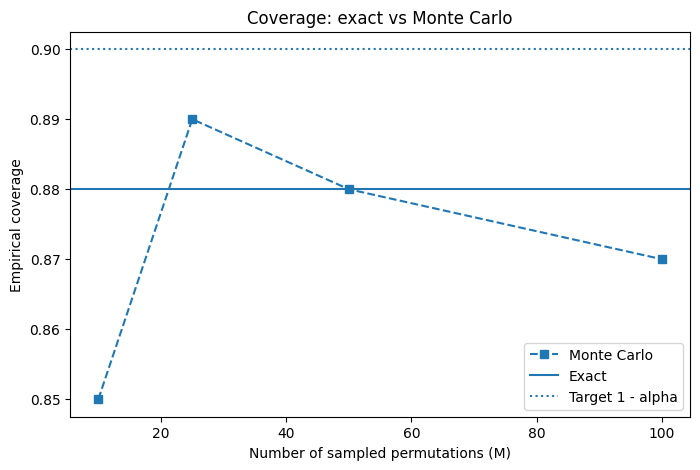

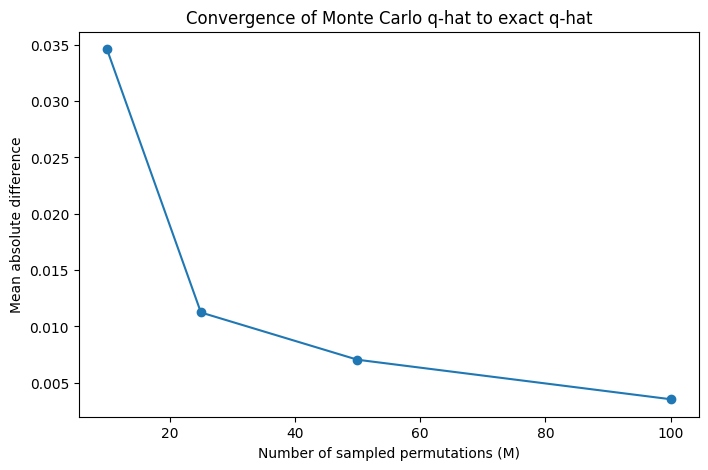

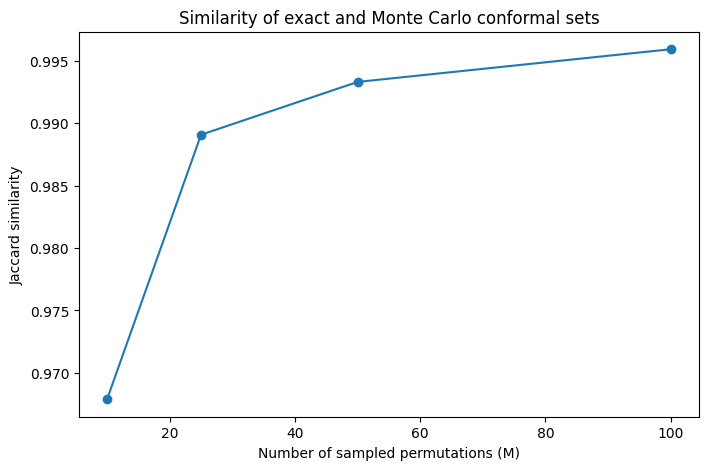

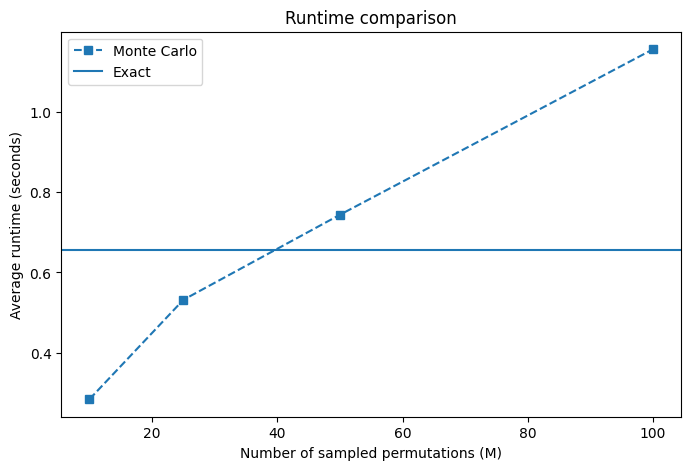

In [ ]:
# ============================================================
# Verification Plots
# ============================================================

# Coverage: Exact vs. Monte Carlo

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    summary_df["mc_permutations"],
    summary_df["empirical_mc_coverage"],
    marker="s",
    linestyle="--",
    label="Monte Carlo",
)

exact_cov = summary_df["empirical_exact_coverage"].iloc[0]
ax.axhline(exact_cov, linestyle="-", label="Exact")

ax.axhline(1 - 0.10, linestyle=":", label="Target 1 - alpha")

ax.set_xlabel("Number of sampled permutations (M)")
ax.set_ylabel("Empirical coverage")
ax.set_title("Coverage: exact vs Monte Carlo")
ax.legend()
plt.show()

# Convergence of q-hat

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary_df["mc_permutations"], summary_df["mean_abs_qhat_diff"], marker="o")
ax.set_xlabel("Number of sampled permutations (M)")
ax.set_ylabel("Mean absolute difference")
ax.set_title("Convergence of Monte Carlo q-hat to exact q-hat")
plt.show()

# Conformal set comparison via Jaccard Similarity

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary_df["mc_permutations"], summary_df["mean_jaccard_similarity"], marker="o")
ax.set_xlabel("Number of sampled permutations (M)")
ax.set_ylabel("Jaccard similarity")
ax.set_title("Similarity of exact and Monte Carlo conformal sets")
plt.show()

# Runtime comparison

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    summary_df["mc_permutations"],
    summary_df["mean_elapsed_mc_total"],
    marker="s",
    linestyle="--",
    label="Monte Carlo",
)

exact_time = summary_df["mean_elapsed_exact_total"].iloc[0]
ax.axhline(exact_time, linestyle="-", label="Exact")

ax.set_xlabel("Number of sampled permutations (M)")
ax.set_ylabel("Average runtime (seconds)")
ax.set_title("Runtime comparison")
ax.legend()
plt.show()

NameError: name 'alpha' is not defined

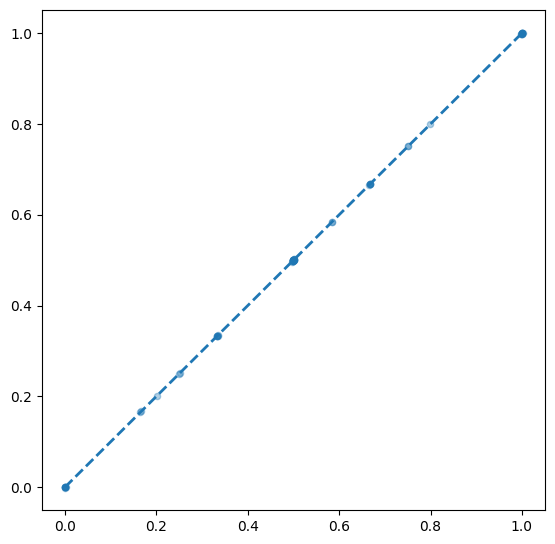

In [ ]:
# ============================================================
# Pathwise q-hat Scatter
# ============================================================

q_exact = one_raw["q_exact"]
q_mc = one_raw["q_mc"]

keys = sorted(q_exact.keys())
exact_vals = np.array([q_exact[k] for k in keys], dtype=float)
mc_vals = np.array([q_mc[k] for k in keys], dtype=float)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(exact_vals, mc_vals, alpha=0.6)
lims = [min(exact_vals.min(), mc_vals.min()), max(exact_vals.max(), mc_vals.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("Exact q-hat")
ax.set_ylabel("Monte Carlo q-hat")
ax.set_title("Pathwise comparison of exact and Monte Carlo q-hat")
plt.show()

### 12. Verification with varying T1

In [ ]:
# ============================================================
# SECTION: Runtime Scaling in T1
# ============================================================

def run_runtime_scaling_study(
    P_true,
    B_true,
    T=40,
    T1_grid=(6, 7, 8, 9, 10),
    alpha=0.10,
    mc_permutations=50,
    n_replications=20,
    base_seed=2026,
    batch_size=1048576,
    stop_if_too_many_paths=None,
):
    """
    Compare exact vs Monte Carlo runtime as future horizon T1 increases.

    Parameters
    ----------
    P_true, B_true : np.ndarray
        HMM parameters.
    T : int
        Past sample length.
    T1_grid : iterable of int
        Future horizons to test.
    alpha : float
        Threshold used for conformal set construction.
    mc_permutations : int
        Number of sampled permutations for Monte Carlo.
    n_replications : int
        Number of simulated datasets per T1.
    base_seed : int
        Base random seed.
    batch_size : int
        Passed to SinglePath.
    stop_if_too_many_paths : int or None
        Optional safety cutoff. If number of candidate paths exceeds this,
        skip that T1.

    Returns
    -------
    scaling_df : pd.DataFrame
        One row per replication and T1.
    summary_df : pd.DataFrame
        Aggregated summary by T1.
    """
    rows = []

    n_states = P_true.shape[0]

    for T1 in T1_grid:
        n_candidate_paths = n_states ** T1

        if stop_if_too_many_paths is not None and n_candidate_paths > stop_if_too_many_paths:
            print(f"Skipping T1={T1}: {n_candidate_paths} candidate paths exceeds cutoff.")
            continue

        print(f"\nRunning T1 = {T1} ({n_candidate_paths} candidate paths)")

        for r in range(n_replications):
            seed = base_seed + 10000 * T1 + r

            sim = make_simulated_dataset(
                P_true=P_true,
                B_true=B_true,
                T=T,
                T1=T1,
                seed=seed,
            )

            X = sim["X"]
            Y = sim["Y"]
            true_future_path = sim["true_future_path"]
            state_values = sim["state_values"]
            obs_values = sim["obs_values"]

            # Exact
            t0 = time.perf_counter()
            model_exact, q_exact, df_exact = fit_model_simulated(
                use_all_permutations=True,
                max_permutations=None,
                X=X,
                Y=Y,
                T=T,
                T1=T1,
                state_values=state_values,
                obs_values=obs_values,
                random_seed=seed,
                batch_size=batch_size,
            )
            elapsed_exact_total = time.perf_counter() - t0
            C_exact = model_exact.conformal_set_from_qhats(q_exact, threshold=alpha)

            # MC
            t1 = time.perf_counter()
            model_mc, q_mc, df_mc = fit_model_simulated(
                use_all_permutations=False,
                max_permutations=mc_permutations,
                X=X,
                Y=Y,
                T=T,
                T1=T1,
                state_values=state_values,
                obs_values=obs_values,
                random_seed=seed,
                batch_size=batch_size,
            )
            elapsed_mc_total = time.perf_counter() - t1
            C_mc = model_mc.conformal_set_from_qhats(q_mc, threshold=alpha)

            qhat_stats = summarize_qhat_difference(q_exact, q_mc)

            rows.append({
                "replication": r,
                "seed": seed,
                "T": T,
                "T1": T1,
                "n_candidate_paths": n_candidate_paths,
                "alpha": alpha,
                "mc_permutations": mc_permutations,
                "true_future_path": true_future_path,
                "exact_covered": int(true_future_path in C_exact),
                "mc_covered": int(true_future_path in C_mc),
                "exact_set_size": len(C_exact),
                "mc_set_size": len(C_mc),
                "jaccard_similarity": jaccard_similarity(C_exact, C_mc),
                "elapsed_exact_total": elapsed_exact_total,
                "elapsed_mc_total": elapsed_mc_total,
                "exact_total_permutations_used": df_exact["n_permutations_used"].sum(),
                "mc_total_permutations_used": df_mc["n_permutations_used"].sum(),
                **qhat_stats,
            })

    scaling_df = pd.DataFrame(rows)

    summary_df = (
        scaling_df
        .groupby("T1", as_index=False)
        .agg(
            mean_n_candidate_paths=("n_candidate_paths", "mean"),
            empirical_exact_coverage=("exact_covered", "mean"),
            empirical_mc_coverage=("mc_covered", "mean"),
            mean_exact_set_size=("exact_set_size", "mean"),
            mean_mc_set_size=("mc_set_size", "mean"),
            mean_jaccard_similarity=("jaccard_similarity", "mean"),
            mean_abs_qhat_diff=("mean_abs_qhat_diff", "mean"),
            mean_rmse_qhat=("rmse_qhat", "mean"),
            mean_elapsed_exact_total=("elapsed_exact_total", "mean"),
            mean_elapsed_mc_total=("elapsed_mc_total", "mean"),
            mean_exact_total_permutations_used=("exact_total_permutations_used", "mean"),
            mean_mc_total_permutations_used=("mc_total_permutations_used", "mean"),
        )
    )

    summary_df["runtime_speedup_exact_over_mc"] = (
        summary_df["mean_elapsed_exact_total"] / summary_df["mean_elapsed_mc_total"]
    )

    return scaling_df, summary_df

In [ ]:
def plot_runtime_scaling(summary_df, mc_permutations):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        summary_df["T1"],
        summary_df["mean_elapsed_exact_total"],
        marker="o",
        linewidth=2,
        label="Exact"
    )
    ax.plot(
        summary_df["T1"],
        summary_df["mean_elapsed_mc_total"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"Monte Carlo (M={mc_permutations})"
    )

    ax.set_xlabel("Future horizon T1")
    ax.set_ylabel("Average runtime (seconds)")
    ax.set_title("Runtime growth with future horizon")
    ax.legend()
    plt.show()

In [ ]:
def plot_runtime_scaling_log(summary_df, mc_permutations):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        summary_df["T1"],
        summary_df["mean_elapsed_exact_total"],
        marker="o",
        linewidth=2,
        label="Exact"
    )
    ax.plot(
        summary_df["T1"],
        summary_df["mean_elapsed_mc_total"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"Monte Carlo (M={mc_permutations})"
    )

    ax.set_yscale("log")
    ax.set_xlabel("Future horizon T1")
    ax.set_ylabel("Average runtime (log scale)")
    ax.set_title("Runtime growth with future horizon")
    ax.legend()
    plt.show()


Running T1 = 6 (64 candidate paths)

Running T1 = 7 (128 candidate paths)

Running T1 = 8 (256 candidate paths)

Running T1 = 9 (512 candidate paths)

Running T1 = 10 (1024 candidate paths)


,T1,mean_n_candidate_paths,empirical_exact_coverage,empirical_mc_coverage,mean_exact_set_size,mean_mc_set_size,mean_jaccard_similarity,mean_abs_qhat_diff,mean_rmse_qhat,mean_elapsed_exact_total,mean_elapsed_mc_total,mean_exact_total_permutations_used,mean_mc_total_permutations_used,runtime_speedup_exact_over_mc
0,6,64.0,0.65,0.65,52.55,52.55,1.000000,0.001266,0.005527,0.023402,0.053812,240.2,589.9,0.434890
1,7,128.0,0.95,0.95,108.30,108.40,0.998250,0.003536,0.010989,0.059463,0.125803,656.4,1535.7,0.472669
2,8,256.0,0.90,0.90,238.20,238.75,0.995616,0.005702,0.012967,0.169509,0.278502,1753.6,3611.5,0.608643
3,9,512.0,0.95,0.90,451.45,452.00,0.991262,0.009177,0.019333,0.842454,0.841015,6787.8,10123.4,1.001711
4,10,1024.0,1.00,1.00,951.30,951.30,0.990032,0.012506,0.024759,3.523991,2.177482,21385.8,24037.7,1.618379


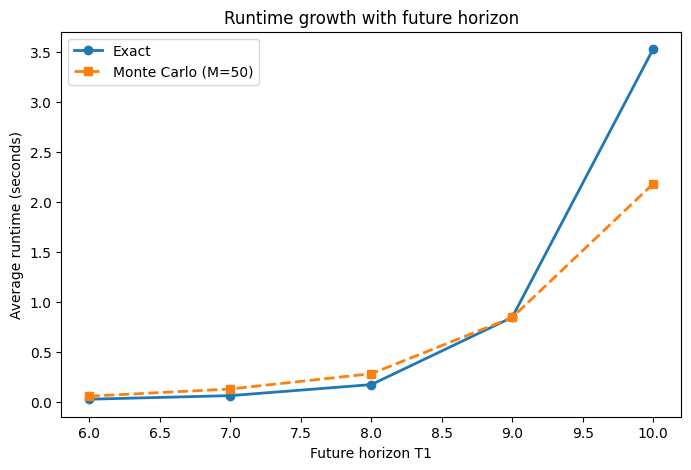

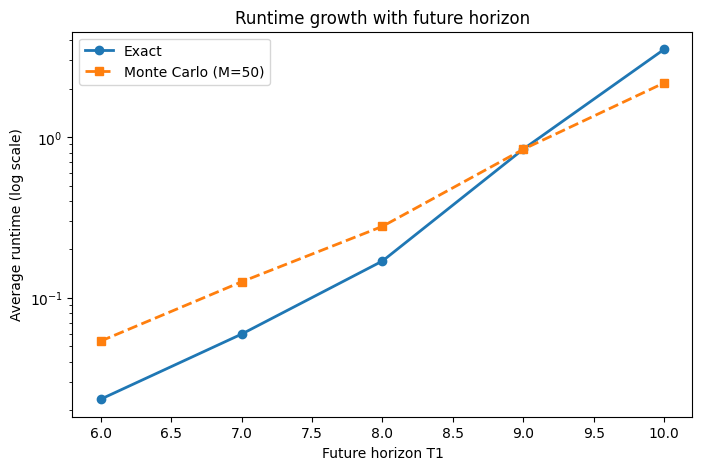

In [ ]:
scaling_df, scaling_summary = run_runtime_scaling_study(
    P_true=P_true,
    B_true=B_true,
    T=40,
    T1_grid=(6, 7, 8, 9, 10),
    alpha=0.10,
    mc_permutations=50,
    n_replications=20,
    base_seed=2026,
    stop_if_too_many_paths=2000,   # safety cutoff
)

display(scaling_summary)
plot_runtime_scaling(scaling_summary, mc_permutations=50)
plot_runtime_scaling_log(scaling_summary, mc_permutations=50)